In [81]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

# Functions

In [82]:
def normalize_signal(signal):
  """
  Normalizes a signal using the formula (signal - median(signal)) / median(signal).

  Args:
    signal: The 1D signal array.

  Returns:
    The normalized signal array.
  """
  signal_median = np.median(signal)
  if signal_median == 0:
      # Handle the case where the median is zero to avoid division by zero
      return signal - signal_median # Or raise an error, depending on desired behavior
  return (signal - signal_median) / signal_median

In [83]:
def find_signal_peaks(signal, height=None, threshold=None, distance=None, prominence=None, width=None, wlen=None, rel_height=0.5, plateau_size=None):
  """
  Finds peaks in a 1D signal.

  Args:
    signal: The 1D signal array.
    height: Required height of peaks.
    threshold: Required threshold of peaks.
    distance: Required distance between peaks.
    prominence: Required prominence of peaks.
    width: Required width of peaks.
    wlen: A window length in samples to consider for the calculation of the peak prominences,
          if it is not specified, the whole signal is used.
    rel_height: Used for width calculation.
    plateau_size: Required size of the plateau of peaks.

  Returns:
    An array of peak indices.
  """
  peaks, _ = find_peaks(signal, height=height, threshold=threshold, distance=distance, prominence=prominence, width=width, wlen=wlen, rel_height=rel_height, plateau_size=plateau_size)
  return peaks

In [84]:
def read_imagej_csv(file_path):
  """
  Reads an ImageJ save data CSV and returns the 'Mean' column as a numpy array.

  Args:
    file_path: The path to the ImageJ save data CSV file.

  Returns:
    A numpy array containing the 'Mean' column data.
  """
  df = pd.read_csv(file_path)
  if 'Mean' in df.columns:
    return df['Mean'].to_numpy()
  else:
    raise ValueError("The CSV file does not contain a 'Mean' column.")

In [85]:
def event_triggered_average(signal, event_indices, window_size):
  """
  Computes the event-triggered average of a signal.

  Args:
    signal: The 1D signal array.
    event_indices: An array of indices indicating the location of events.
    window_size: The size of the window around each event to consider for the average.
                 The window will be centered around the event index, with
                 window_size//2 samples before and window_size//2 samples after the event.

  Returns:
    A tuple containing:
      - average_signal: The computed event-triggered average signal.
      - individual_signals: An array of individual signal portions around each event.
  """
  individual_signals = []
  for event_index in event_indices:
    start_index = max(0, event_index - window_size // 2)
    end_index = min(len(signal), event_index + window_size // 2 + 1)
    individual_signals.append(signal[start_index:end_index])

  # Pad or truncate individual signals to have the same length
  max_len = max(len(sig) for sig in individual_signals)
  padded_signals = np.array([np.pad(sig, (0, max_len - len(sig)), 'constant', constant_values=np.nan) for sig in individual_signals])

  average_signal = np.nanmean(padded_signals, axis=0)

  return average_signal, padded_signals

In [86]:
def detrend_double_exponential(signal):
  """
  Fits a double exponential to a signal and returns the coefficients and detrended signal.

  Args:
    signal: The 1D numpy array to be detrended.

  Returns:
    A tuple containing:
      - params: The fitted coefficients (a1, tau1, a2, tau2, c) or None if fitting fails.
      - detrended_signal: The detrended signal or None if fitting fails.
      - success: A boolean indicating whether the fitting was successful.
  """
  x_data = np.arange(len(signal))
  try:
    with warnings.catch_warnings():
        warnings.filterwarnings("error", category=OptimizeWarning)
        params, pcov = curve_fit(double_exponential, x_data, signal)
    # Calculate the fitted signal and detrend
    fitted_signal = double_exponential(x_data, *params)
    detrended_signal = signal - fitted_signal
    return params, detrended_signal, True
  except (RuntimeError, ValueError, OptimizeWarning):
    return None, None, False # Indicate failure

In [87]:
def double_exponential(x, a1, tau1, a2, tau2, c):
  """
  Calculates the value of a double exponential decay function.

  Args:
    x: A numpy array representing the independent variable.
    a1: Amplitude of the first exponential component.
    tau1: Time constant of the first exponential component.
    a2: Amplitude of the second exponential component.
    tau2: Time constant of the second exponential component.
    c: Offset.

  Returns:
    A numpy array containing the calculated double exponential values.
  """
  return a1 * np.exp(-x / tau1) + a2 * np.exp(-x / tau2) + c

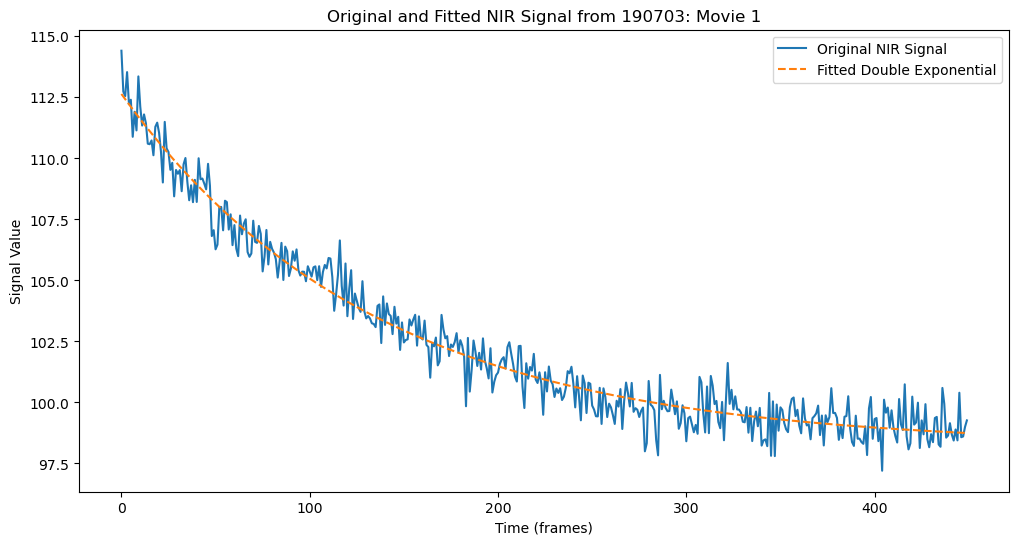

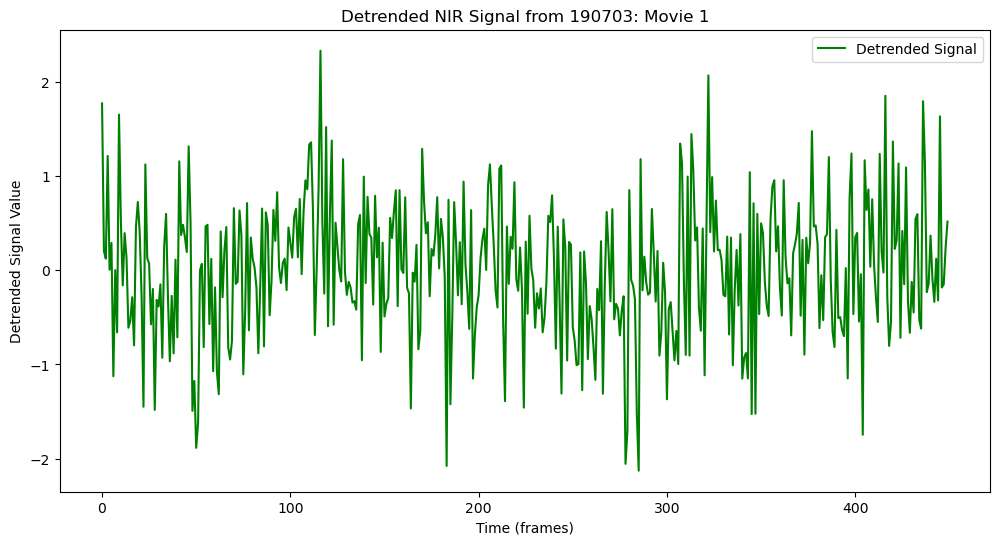

In [88]:
# Select one of the NIR signals for testing (e.g., the first one from dfwaves)
# You can change the index [0] to select a different row/signal
test_row = dfwaves.iloc[0]
test_nir_filename = test_row['nir data']
test_nir_filepath = os.path.join(basepath, wavedatafolder, test_nir_filename)
test_nir_data = read_imagej_csv(test_nir_filepath)

# Apply the detrending function
params, detrended_signal, success = detrend_double_exponential(test_nir_data)

# Plot the results
if success:
  x_data = np.arange(len(test_nir_data))
  fitted_signal = double_exponential(x_data, *params)

  # Plot original and fitted signals
  plt.figure(figsize=(12, 6))
  plt.plot(test_nir_data, label='Original NIR Signal')
  plt.plot(fitted_signal, label='Fitted Double Exponential', linestyle='--')
  plt.xlabel('Time (frames)')
  plt.ylabel('Signal Value')
  plt.title(f"Original and Fitted NIR Signal from {test_row['date']}: Movie {test_row['movie']}")
  plt.legend()
  plt.show()

  # Plot detrended signal in a separate figure
  plt.figure(figsize=(12, 6))
  plt.plot(detrended_signal, label='Detrended Signal', color='green')
  plt.xlabel('Time (frames)')
  plt.ylabel('Detrended Signal Value')
  plt.title(f"Detrended NIR Signal from {test_row['date']}: Movie {test_row['movie']}")
  plt.legend()
  plt.show()

else:
  print(f"Double exponential fitting failed for the selected NIR signal from {test_row['date']}: Movie {test_row['movie']}.")

# Waves

## Load metadata table

In [89]:
wavemetafile = 'dopamine imaging.csv'
wavedatafolder = 'waves'
basepath = r"C:\Users\fsch9\Documents\GitHub\nIR catecholamine sensor"

df = pd.read_csv(os.path.join(basepath, wavemetafile))

# Remove trailing spaces from column headers
df.columns = df.columns.str.strip()

# Select the wave experiment rows
dfwaves = df[df['experiment'] == 'waves']

# Display the first 5 rows of the DataFrame
display(dfwaves.head())

,date,movie,age,experiment,notes,sensor,depth below ilm microns,nir data,cal520 data
0,190703,1,9.0,waves,NaN,negative control,0,190703 - nanotubes001 nir.csv,190703 - nanotubes001 cal520.csv
1,190703,2,9.0,waves,burning rgc layer,nircat,0,190703 - sensor002 nircat.csv,190703 - sensor002 cal520.csv
2,190703,3,9.0,waves,boosted laser power,nircat,15,190703 - sensor003 nircat.csv,190703 - sensor003 cal520.csv
3,190703,4,9.0,waves,NaN,nircat,20,190703 - sensor004 nircat.csv,190703 - sensor004 cal520.csv
6,190704,10,NaN,waves,NaN,nircat,na,190704 sensor 010 nircat.csv,190704 sensor 010 cal520.csv


## Event-triggered averages


=== Analysis for 190703: Movie 1 ===


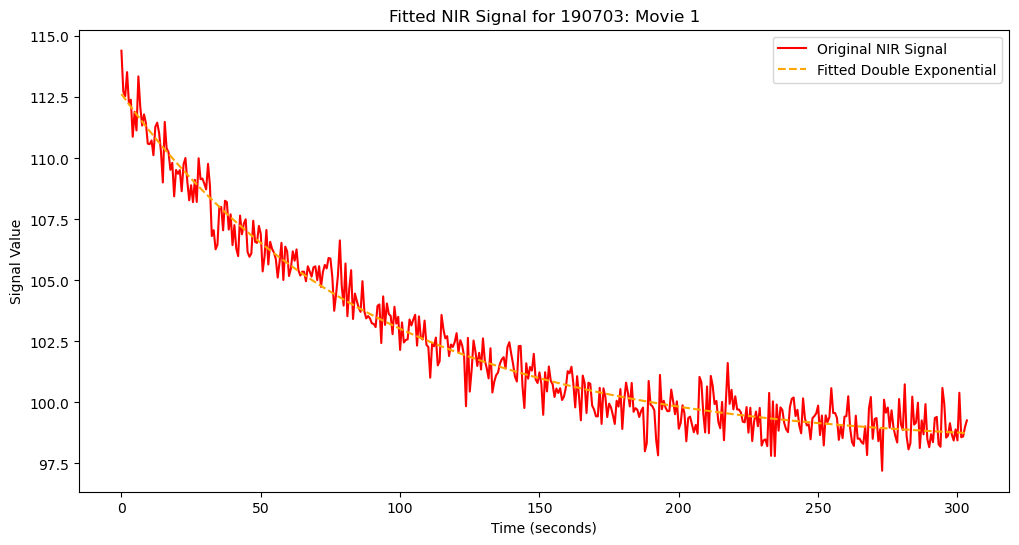

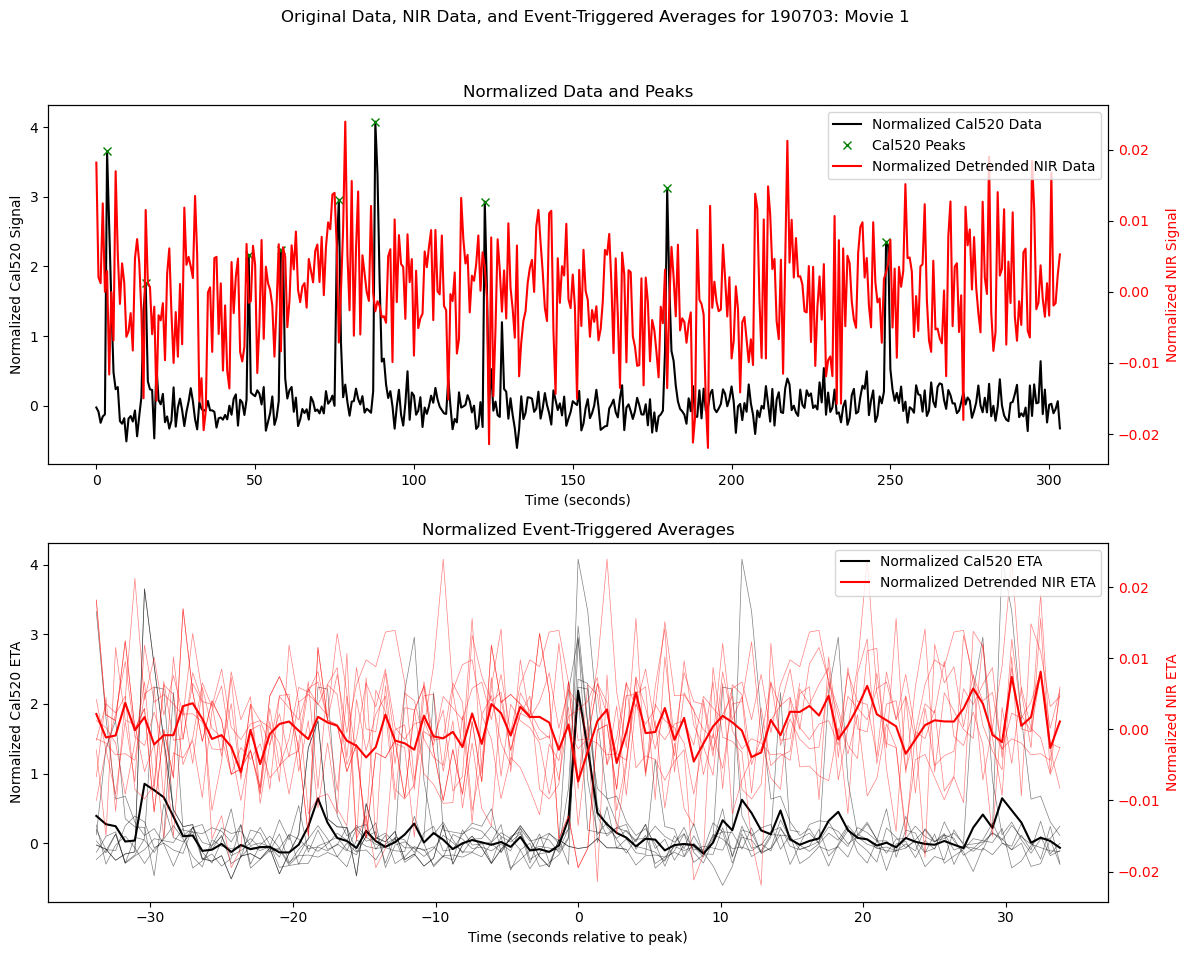

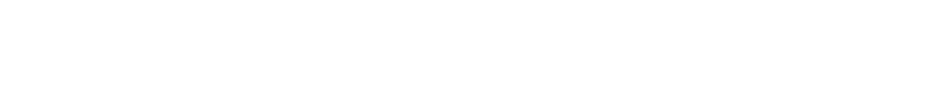


=== Analysis for 190703: Movie 2 ===


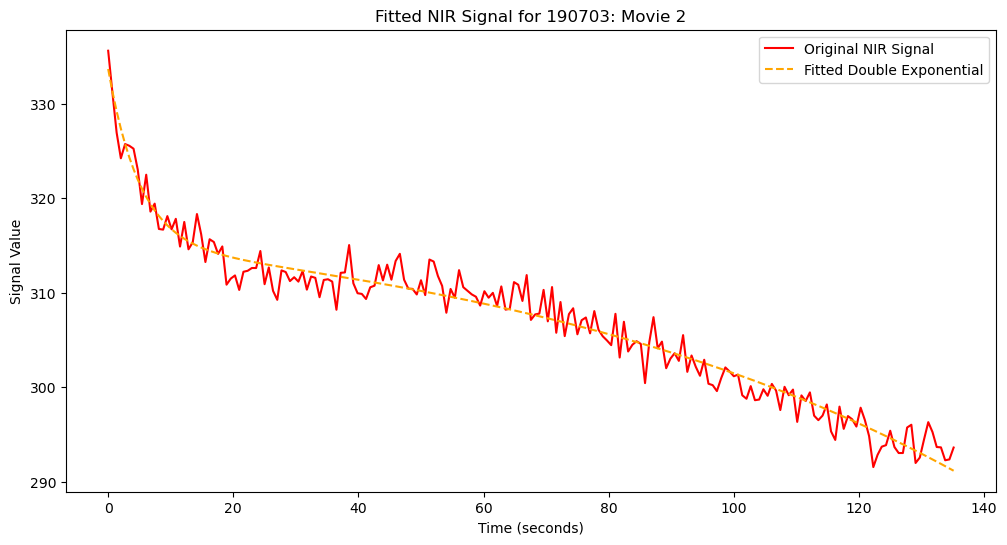

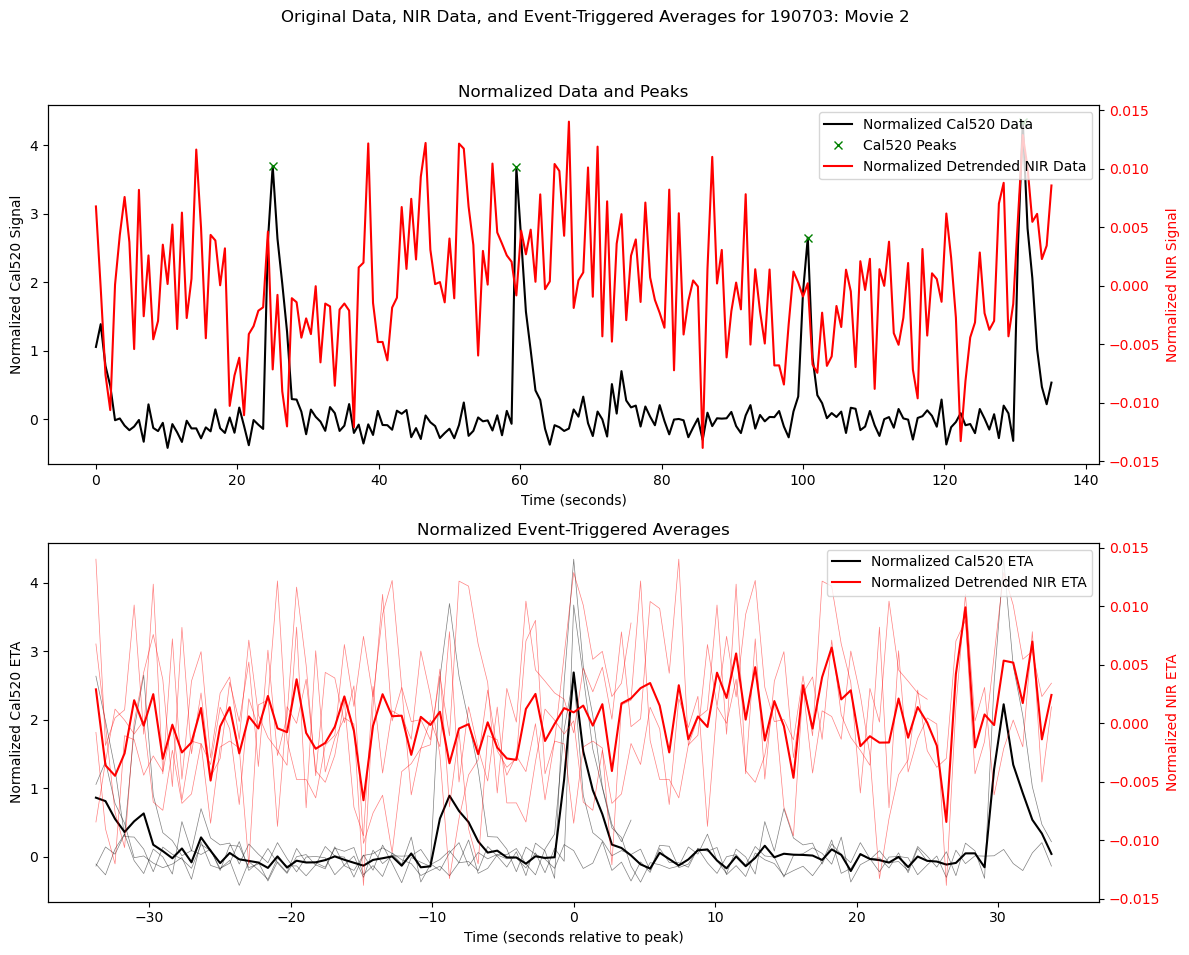

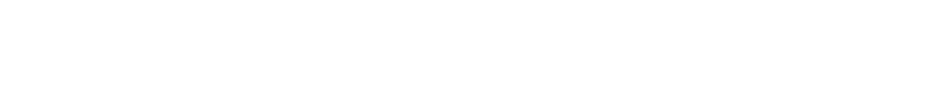


=== Analysis for 190703: Movie 3 ===


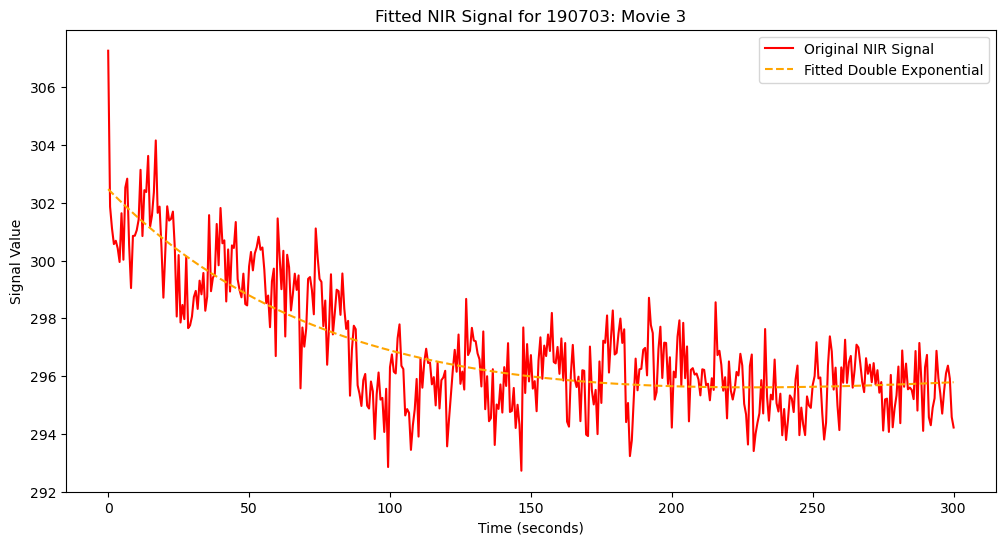

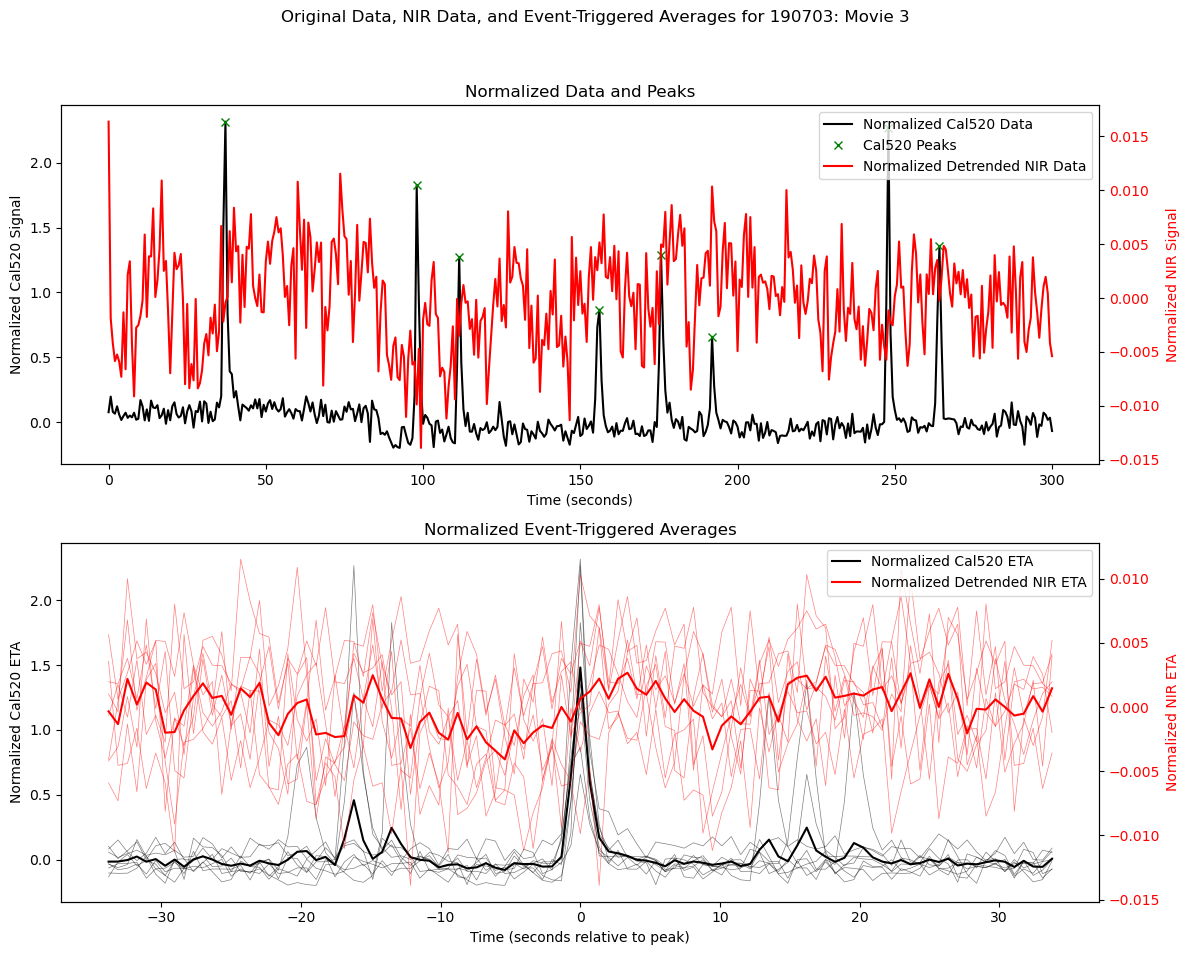

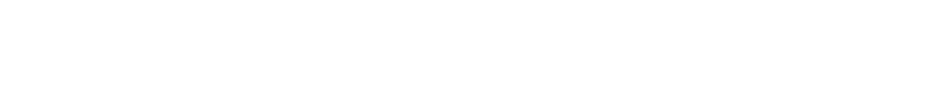


=== Analysis for 190703: Movie 4 ===


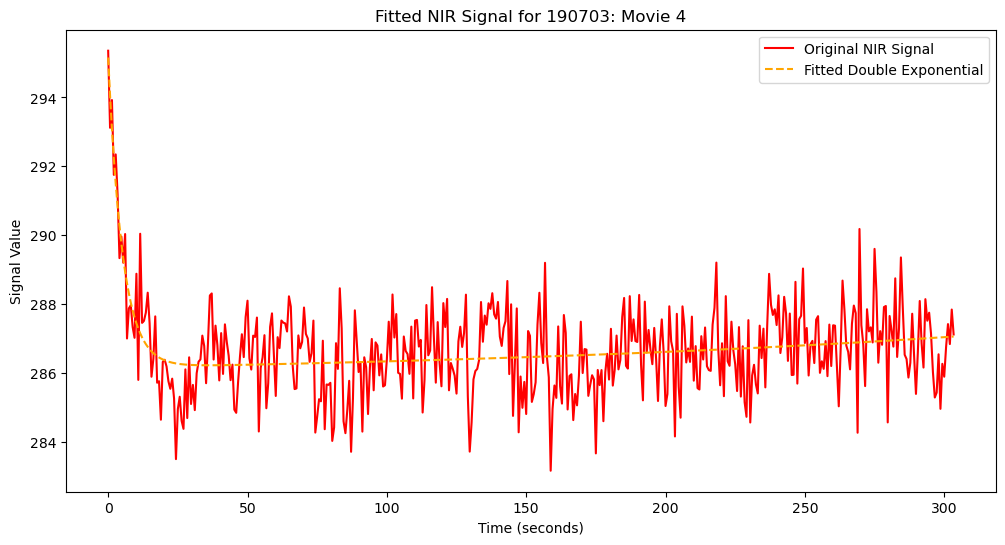

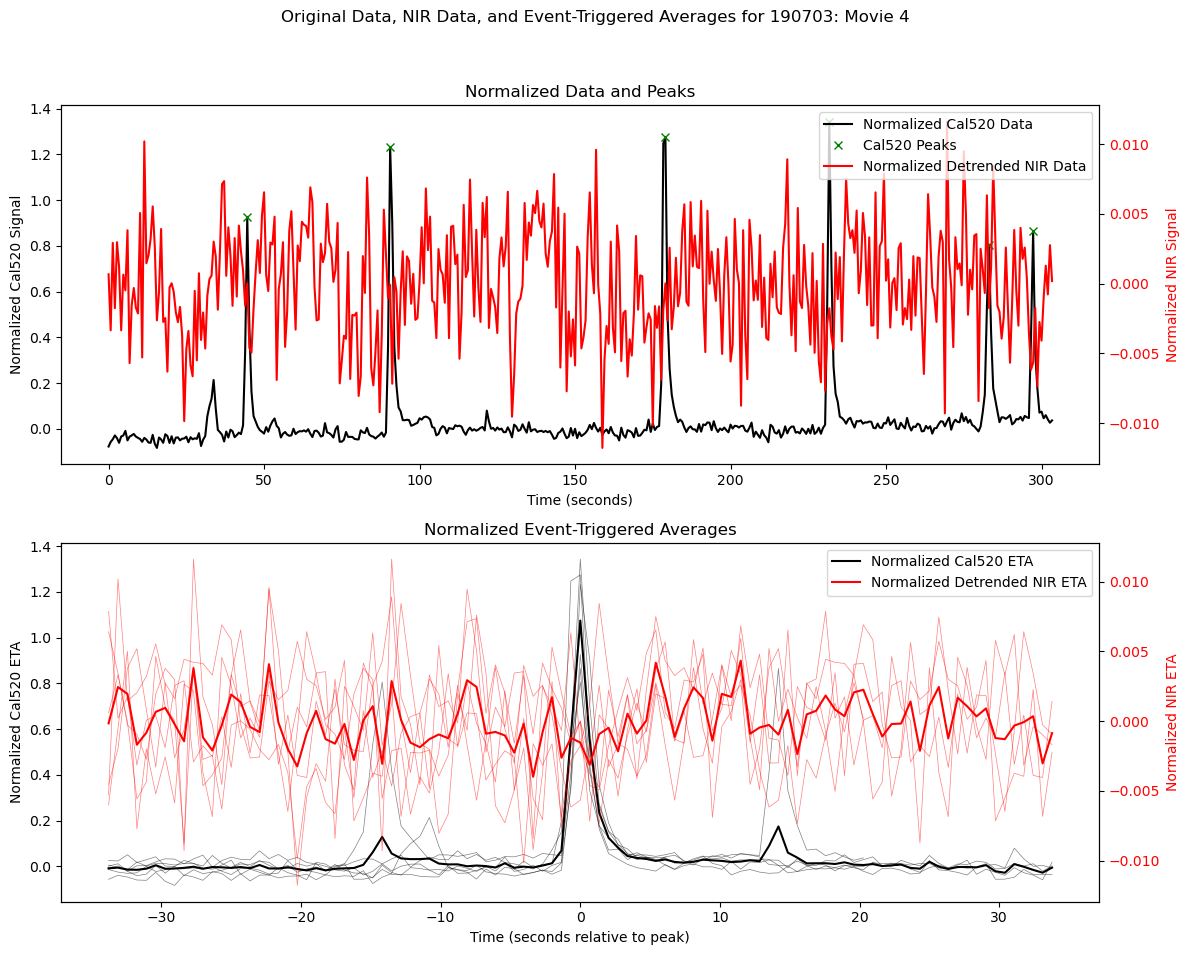

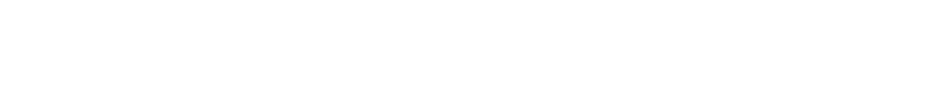


=== Analysis for 190704: Movie 10 ===


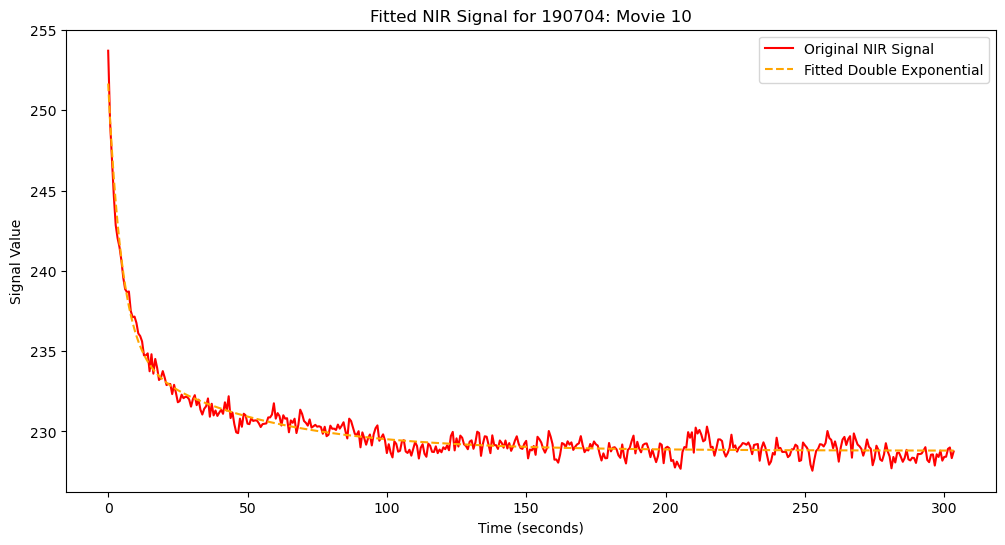

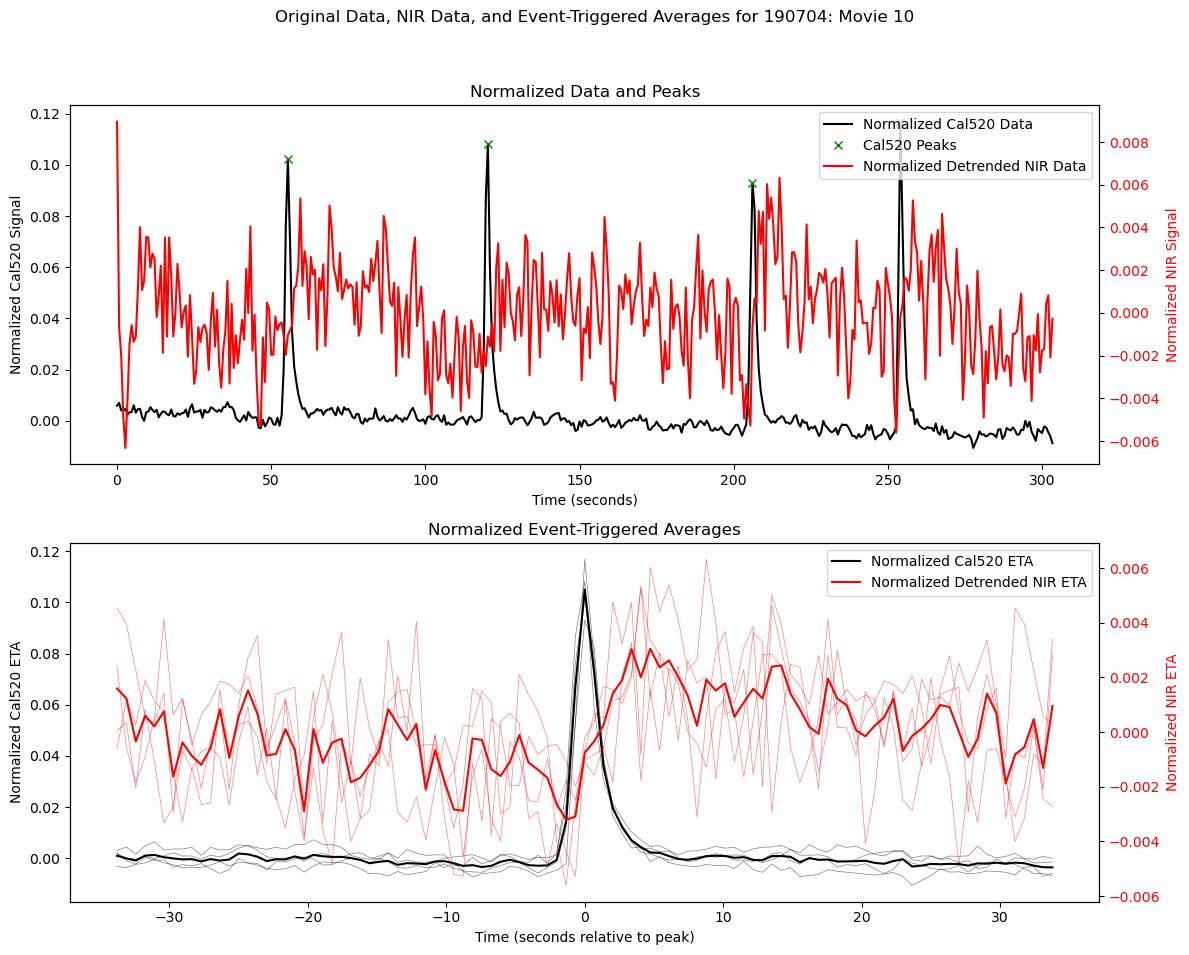

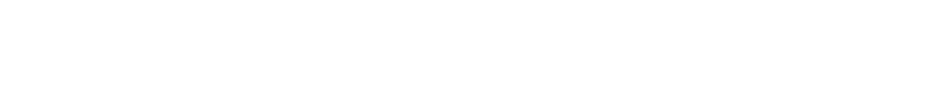


=== Analysis for 190709: Movie 11 ===
Double exponential fitting failed for NIR signal in row 9. Proceeding without detrended NIR data.


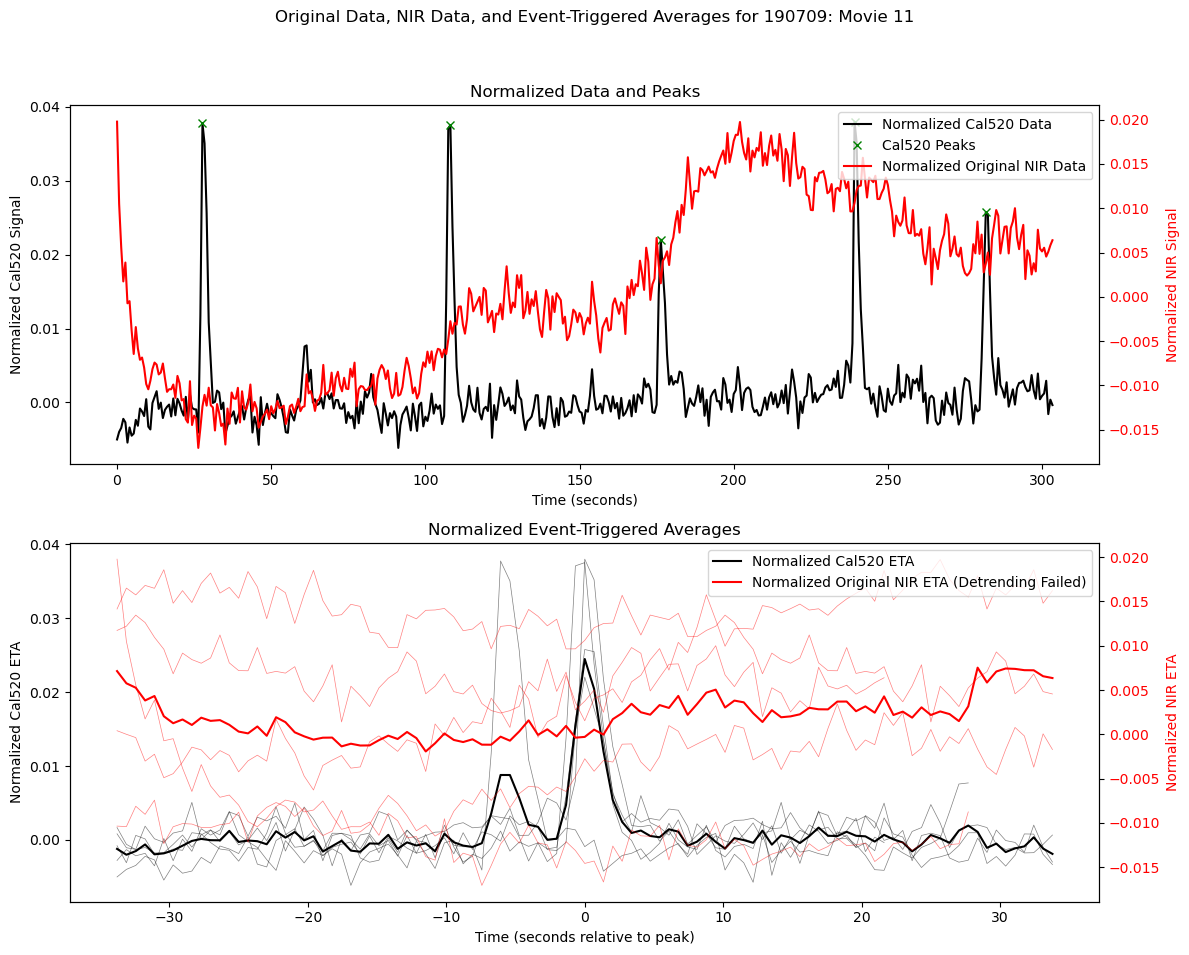

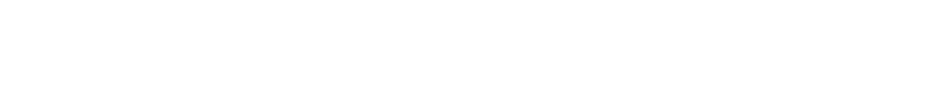


=== Measured Average NIR ETA Values Around Maximum ===


,date,movie,sensor,depth,avg_pre_peak_nir,avg_post_peak_nir
0,190703,1,negative control,0,0.001267,0.001430
1,190703,2,nircat,0,0.000747,0.002656
2,190703,3,nircat,15,-0.000917,0.002103
3,190703,4,nircat,20,0.001966,0.002002
4,190704,10,nircat,na,-0.000773,0.002474
5,190709,11,nircat,24,0.000617,0.004878


In [94]:
window_size = 100 # Define a window size for event-triggered average
framerate = 1.48 # Hz

# List to store measured average NIR ETA values around maximum
avg_nir_eta_values = []

for index, row in dfwaves.iterrows():
  cal520_filename = row['cal520 data']
  nir_filename = row['nir data']

  print(f"\n=== Analysis for {row['date']}: Movie {row['movie']} ===") # Print the heading before plots

  try:
    # Construct full file paths
    cal520_filepath = os.path.join(basepath, wavedatafolder, cal520_filename)
    nir_filepath = os.path.join(basepath, wavedatafolder, nir_filename)

    # Read the cal520 and nir data
    cal520_data = read_imagej_csv(cal520_filepath)
    nir_data = read_imagej_csv(nir_filepath)

    # Detrend the NIR data
    params, detrended_nir_data, success = detrend_double_exponential(nir_data)

    # Calculate the fitted signal for plotting if fitting was successful
    fitted_nir_signal = None
    if success:
        x_data = np.arange(len(nir_data))
        fitted_nir_signal = double_exponential(x_data, *params)
        # Add back the minimum of the original signal to the detrended signal for normalization
        nir_data_for_processing = detrended_nir_data + np.min(nir_data)
        nir_data_label = 'Detrended NIR Data'
        nir_eta_label = 'Detrended NIR ETA'
    else:
      print(f"Double exponential fitting failed for NIR signal in row {index}. Proceeding without detrended NIR data.")
      nir_data_for_processing = nir_data # Use original data if detrending fails
      nir_data_label = 'Original NIR Data'
      nir_eta_label = 'Original NIR ETA (Detrending Failed)'


    # Normalize both signals
    cal520_data_normalized = normalize_signal(cal520_data)
    nir_data_normalized = normalize_signal(nir_data_for_processing)


    # Find peaks in the normalized cal520 data
    cal520_peaks = find_signal_peaks(cal520_data_normalized, height=np.mean(cal520_data_normalized) + 2 * np.std(cal520_data_normalized))

    # Compute event-triggered average for normalized signals using cal520 peaks
    if len(cal520_peaks) > 0:
      cal520_eta, cal520_padded = event_triggered_average(cal520_data_normalized, cal520_peaks, window_size)
      nir_eta_to_plot, nir_padded_to_plot = event_triggered_average(nir_data_normalized, cal520_peaks, window_size)

      # Calculate time arrays for plotting
      time_original = np.arange(len(cal520_data)) / framerate
      time_eta = np.arange(len(cal520_eta)) / framerate - window_size // 2 / framerate

      # Measure average of three frames around the maximum values in NIR ETA
      pre_peak_window_end_time = 0 # 0 seconds relative to peak is the peak
      pre_peak_window_start_time = -10 # 10 seconds before peak
      post_peak_window_start_time = 0 # 0 seconds relative to peak is the peak
      post_peak_window_end_time = 10 # 10 seconds after peak

      # Find indices corresponding to the time windows
      pre_peak_start_index = np.searchsorted(time_eta, pre_peak_window_start_time)
      pre_peak_end_index = np.searchsorted(time_eta, pre_peak_window_end_time)
      post_peak_start_index = np.searchsorted(time_eta, post_peak_window_start_time)
      post_peak_end_index = np.searchsorted(time_eta, post_peak_window_end_time)

      # Ensure indices are within bounds
      pre_peak_start_index = max(0, pre_peak_start_index)
      pre_peak_end_index = min(len(time_eta), pre_peak_end_index)
      post_peak_start_index = max(0, post_peak_start_index)
      post_peak_end_index = min(len(time_eta), post_peak_end_index)

      # Measure average of three frames around max values
      pre_peak_window_data = nir_eta_to_plot[pre_peak_start_index:pre_peak_end_index]
      post_peak_window_data = nir_eta_to_plot[post_peak_start_index:post_peak_end_index]

      # Find the index of the maximum within the windows (relative to the start of the window)
      if len(pre_peak_window_data) > 0:
          max_pre_peak_index_relative = np.nanargmax(pre_peak_window_data)
          # Calculate the index in the original ETA array
          max_pre_peak_index_absolute = pre_peak_start_index + max_pre_peak_index_relative
          # Define the 3-frame window around the max (handle boundaries)
          avg_window_start_pre = max(pre_peak_start_index, max_pre_peak_index_absolute - 1)
          avg_window_end_pre = min(pre_peak_end_index, max_pre_peak_index_absolute + 2) # +2 to include 3 frames
          avg_pre_peak_nir = np.nanmean(nir_eta_to_plot[avg_window_start_pre:avg_window_end_pre])
      else:
          avg_pre_peak_nir = np.nan # Handle empty window


      if len(post_peak_window_data) > 0:
          max_post_peak_index_relative = np.nanargmax(post_peak_window_data)
           # Calculate the index in the original ETA array
          max_post_peak_index_absolute = post_peak_start_index + max_post_peak_index_relative
          # Define the 3-frame window around the max (handle boundaries)
          avg_window_start_post = max(post_peak_start_index, max_post_peak_index_absolute - 1)
          avg_window_end_post = min(post_peak_end_index, max_post_peak_index_absolute + 2) # +2 to include 3 frames
          avg_post_peak_nir = np.nanmean(nir_eta_to_plot[avg_window_start_post:avg_window_end_post])
      else:
          avg_post_peak_nir = np.nan # Handle empty window


      # Store the measured values
      avg_nir_eta_values.append({
          'date': row['date'],
          'movie': row['movie'],
          'sensor': row['sensor'], # Include sensor
          'depth': row['depth below ilm microns'], # Include depth
          'avg_pre_peak_nir': avg_pre_peak_nir,
          'avg_post_peak_nir': avg_post_peak_nir
          })


      # Plotting
      # Plot fitted NIR signal in a separate figure if successful
      if success:
          plt.figure(figsize=(12, 6))
          plt.plot(time_original, nir_data, label='Original NIR Signal', color='red')
          plt.plot(time_original, fitted_nir_signal, label='Fitted Double Exponential', linestyle='--', color='orange')
          plt.xlabel('Time (seconds)')
          plt.ylabel('Signal Value')
          plt.title(f"Fitted NIR Signal for {row['date']}: Movie {row['movie']}")
          plt.legend()
          plt.show()


      fig, axes = plt.subplots(2, 1, figsize=(12, 10))
      fig.suptitle(f"Original Data, NIR Data, and Event-Triggered Averages for {row['date']}: Movie {row['movie']}") # Moved main title here


      # Plot original data and selected NIR data (normalized)
      ax1 = axes[0]
      ax1.plot(time_original, cal520_data_normalized, label='Normalized Cal520 Data', color='black')
      ax1.set_ylabel('Normalized Cal520 Signal', color='black')
      ax1.tick_params(axis='y', labelcolor='black')
      ax1.set_xlabel('Time (seconds)')
      ax1.set_title('Normalized Data and Peaks') # Subtitle remains

      ax2 = ax1.twinx()
      ax2.plot(time_original, nir_data_normalized, label=f'Normalized {nir_data_label}', color='red')
      ax2.set_ylabel('Normalized NIR Signal', color='red')
      ax2.tick_params(axis='y', labelcolor='red')


      # Mark peaks on the original data plot
      ax1.plot(time_original[cal520_peaks], cal520_data_normalized[cal520_peaks], "x", color='green', label='Cal520 Peaks')

      lines, labels = ax1.get_legend_handles_labels()
      lines2, labels2 = ax2.get_legend_handles_labels()
      ax2.legend(lines + lines2, labels + labels2, loc='upper right')


      # Plot event-triggered averages (normalized)
      ax3 = axes[1]
      ax3.plot(time_eta, cal520_eta, label='Normalized Cal520 ETA', color='black')
      # Plot individual padded signals with correct x-axis
      for i in range(cal520_padded.shape[0]):
          ax3.plot(time_eta[~np.isnan(cal520_padded[i,:])], cal520_padded[i,~np.isnan(cal520_padded[i,:])], color='black', linewidth=0.5, alpha=0.5)

      ax3.set_ylabel('Normalized Cal520 ETA', color='black')
      ax3.tick_params(axis='y', labelcolor='black')
      ax3.set_xlabel('Time (seconds relative to peak)')
      ax3.set_title('Normalized Event-Triggered Averages') # Subtitle remains

      ax4 = ax3.twinx()
      ax4.plot(time_eta, nir_eta_to_plot, label=f'Normalized {nir_eta_label}', color='red')
      # Plot individual padded signals with correct x-axis
      for i in range(nir_padded_to_plot.shape[0]):
          ax4.plot(time_eta[~np.isnan(nir_padded_to_plot[i,:])], nir_padded_to_plot[i,~np.isnan(nir_padded_to_plot[i,:])], color='red', linewidth=0.5, alpha=0.5)

      ax4.set_ylabel('Normalized NIR ETA', color='red')
      ax4.tick_params(axis='y', labelcolor='red')

      lines3, labels3 = ax3.get_legend_handles_labels()
      lines4, labels4 = ax4.get_legend_handles_labels()
      ax4.legend(lines3 + lines4, labels3 + labels4, loc='upper right')


      plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
      plt.show()

      # Add an empty plot to create space between groups of plots
      plt.figure(figsize=(12, 1)) # Adjust figsize to control the height of the space
      plt.axis('off') # Turn off axes for the empty plot
      plt.show()


    else:
      print(f"Processing row {index}: No peaks found in cal520 data, skipping ETA and plotting.")


  except FileNotFoundError:
    print(f"File not found for row {index}: cal520='{cal520_filename}' or nir='{nir_filename}'")
  except ValueError as e:
    print(f"Error processing file for row {index}: {e}")
  except Exception as e:
    print(f"An unexpected error occurred for row {index}: {e}")

# Convert the list of dictionaries to a pandas DataFrame after the loop
avg_nir_eta_df = pd.DataFrame(avg_nir_eta_values)

# Display the DataFrame with the measured values
print("\n=== Measured Average NIR ETA Values Around Maximum ===")
display(avg_nir_eta_df)

# Summary data

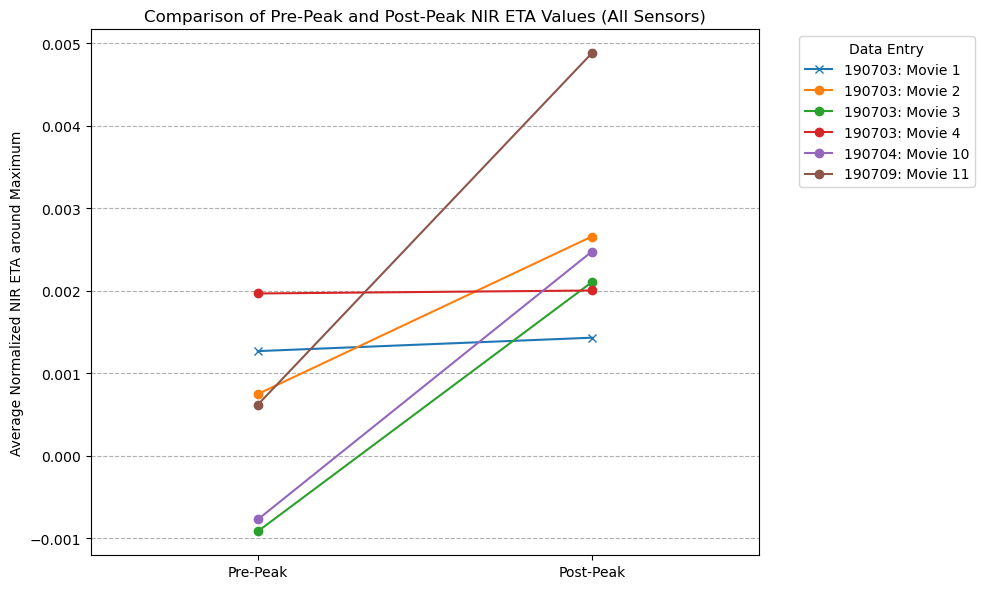

In [97]:
# Create a figure and axes for the plot
plt.figure(figsize=(10, 6))

# Iterate through the entire DataFrame and plot the pre and post peak values with conditional markers
for index, row in avg_nir_eta_df.iterrows():
    marker_style = 'o' # Default marker for 'nircat'
    if row['sensor'] == 'negative control':
        marker_style = 'x' # Use 'x' for 'negative control'

    plt.plot([1, 2], [row['avg_pre_peak_nir'], row['avg_post_peak_nir']], marker=marker_style, linestyle='-', label=f"{row['date']}: Movie {row['movie']}")

# Set the x-axis labels and limits
plt.xticks([1, 2], ['Pre-Peak', 'Post-Peak'])
plt.xlim(0.5, 2.5)

# Add labels and title
plt.ylabel('Average Normalized NIR ETA around Maximum')
plt.title('Comparison of Pre-Peak and Post-Peak NIR ETA Values (All Sensors)')
plt.legend(title='Data Entry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--')

# Adjust layout to prevent legend overlap
plt.tight_layout()

# Show the plot
plt.show()